# CPU vs RAPIDS Performance Comparison
## London Airbnb Data Intelligence Project

### Objective
Compare **pandas (CPU)** and **RAPIDS/cuDF (GPU)** on representative data-processing operations from the London Airbnb EDA using the same cleaned dataset.

The comparison focuses on execution time and speedup:

**Speedup = CPU Time / GPU Time**

Visualization rendering is excluded because the benchmark focuses on data-processing performance.

In [3]:
!nvidia-smi

Tue Oct  6 21:17:44 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   48C    P8             13W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

### Benchmark Environment

- **GPU:** NVIDIA Tesla T4
- **GPU Memory:** 15 GB
- **CUDA Version:** 13.0
- **Environment:** Google Colab

## 1. CPU Benchmark - pandas

The cleaned dataset is processed with pandas on the CPU. Representative operations from the project are timed and will later be repeated with RAPIDS on the GPU.

In [8]:
import pandas as pd
import numpy as np
import time

FILE = "/listings_clean.csv"

cpu_times = {}

# 1. Load cleaned dataset
start = time.perf_counter()
df_cpu = pd.read_csv(FILE, low_memory=False)
cpu_times["Load CSV"] = time.perf_counter() - start

print(f"Dataset shape: {df_cpu.shape}")
print(f"Load time: {cpu_times['Load CSV']:.4f} sec")

Dataset shape: (92635, 80)
Load time: 3.3973 sec


In [9]:
# Representative CPU operations

# 2. Filter rated listings
start = time.perf_counter()
rated_cpu = df_cpu[df_cpu["top_rated"].notna()].copy()
cpu_times["Filter Rated Listings"] = time.perf_counter() - start

# 3. Room type aggregation
start = time.perf_counter()
room_cpu = rated_cpu.groupby("room_type")["top_rated"].agg(["count", "mean"])
cpu_times["Room Type GroupBy"] = time.perf_counter() - start

# 4. Borough aggregation
start = time.perf_counter()
borough_cpu = rated_cpu.groupby("neighbourhood_cleansed")["top_rated"].agg(["count", "mean"])
cpu_times["Borough GroupBy"] = time.perf_counter() - start

# 5. Capacity aggregation
start = time.perf_counter()
capacity_cpu = rated_cpu.groupby("accommodates")["top_rated"].agg(["count", "mean"])
cpu_times["Capacity GroupBy"] = time.perf_counter() - start

# 6. Minimum nights aggregation
start = time.perf_counter()
nights_cpu = rated_cpu.groupby("minimum_nights_capped")["top_rated"].agg(["count", "mean"])
cpu_times["Minimum Nights GroupBy"] = time.perf_counter() - start

# 7. Host type feature + aggregation
start = time.perf_counter()
rated_cpu["host_type"] = np.where(
    rated_cpu["calculated_host_listings_count"] == 1,
    "Single-listing host",
    "Multi-listing host"
)
host_cpu = rated_cpu.groupby("host_type")["top_rated"].agg(["count", "mean"])
cpu_times["Host Type + GroupBy"] = time.perf_counter() - start

# Display CPU timings
cpu_results = pd.DataFrame(
    cpu_times.items(),
    columns=["Operation", "CPU Time (sec)"]
)

cpu_results["CPU Time (sec)"] = cpu_results["CPU Time (sec)"].round(4)

print(f"Rated listings: {len(rated_cpu):,}")
display(cpu_results)

Rated listings: 70,708


,Operation,CPU Time (sec)
0,Load CSV,3.3973
1,Filter Rated Listings,0.0887
2,Room Type GroupBy,0.0159
3,Borough GroupBy,0.0115
4,Capacity GroupBy,0.0064
5,Minimum Nights GroupBy,0.0047
6,Host Type + GroupBy,0.0291


## 2. GPU Benchmark - RAPIDS/cuDF

The same dataset and analytical operations are repeated using RAPIDS cuDF on the NVIDIA Tesla T4 GPU.

In [10]:
import cudf
import cupy as cp

print("cuDF version:", cudf.__version__)
print("CuPy version:", cp.__version__)
print("GPU:", cp.cuda.runtime.getDeviceProperties(0)["name"].decode())

cuDF version: 26.06.00
CuPy version: 14.0.1
GPU: Tesla T4


In [11]:
# GPU benchmark with RAPIDS/cuDF

gpu_times = {}

def sync_gpu():
    cp.cuda.Stream.null.synchronize()

# Small GPU warm-up
_ = cp.arange(1000).sum()
sync_gpu()

# 1. Load CSV
sync_gpu()
start = time.perf_counter()
df_gpu = cudf.read_csv(FILE)
sync_gpu()
gpu_times["Load CSV"] = time.perf_counter() - start

# 2. Filter rated listings
sync_gpu()
start = time.perf_counter()
rated_gpu = df_gpu[df_gpu["top_rated"].notna()].copy()
sync_gpu()
gpu_times["Filter Rated Listings"] = time.perf_counter() - start

# 3. Room type aggregation
sync_gpu()
start = time.perf_counter()
room_gpu = rated_gpu.groupby("room_type")["top_rated"].agg(["count", "mean"])
sync_gpu()
gpu_times["Room Type GroupBy"] = time.perf_counter() - start

# 4. Borough aggregation
sync_gpu()
start = time.perf_counter()
borough_gpu = rated_gpu.groupby("neighbourhood_cleansed")["top_rated"].agg(["count", "mean"])
sync_gpu()
gpu_times["Borough GroupBy"] = time.perf_counter() - start

# 5. Capacity aggregation
sync_gpu()
start = time.perf_counter()
capacity_gpu = rated_gpu.groupby("accommodates")["top_rated"].agg(["count", "mean"])
sync_gpu()
gpu_times["Capacity GroupBy"] = time.perf_counter() - start

# 6. Minimum nights aggregation
sync_gpu()
start = time.perf_counter()
nights_gpu = rated_gpu.groupby("minimum_nights_capped")["top_rated"].agg(["count", "mean"])
sync_gpu()
gpu_times["Minimum Nights GroupBy"] = time.perf_counter() - start

# 7. Host type feature + aggregation
sync_gpu()
start = time.perf_counter()

rated_gpu["host_type"] = (
    rated_gpu["calculated_host_listings_count"] == 1
).astype("int8")

host_gpu = rated_gpu.groupby("host_type")["top_rated"].agg(["count", "mean"])

sync_gpu()
gpu_times["Host Type + GroupBy"] = time.perf_counter() - start

# Display GPU timings
gpu_results = pd.DataFrame(
    gpu_times.items(),
    columns=["Operation", "GPU Time (sec)"]
)

gpu_results["GPU Time (sec)"] = gpu_results["GPU Time (sec)"].round(4)

print(f"GPU dataset shape: {df_gpu.shape}")
print(f"Rated listings: {len(rated_gpu):,}")
display(gpu_results)

GPU dataset shape: (92677, 80)
Rated listings: 70,708


,Operation,GPU Time (sec)
0,Load CSV,1.0641
1,Filter Rated Listings,0.2043
2,Room Type GroupBy,0.1886
3,Borough GroupBy,0.0088
4,Capacity GroupBy,0.0107
5,Minimum Nights GroupBy,0.0117
6,Host Type + GroupBy,0.1313


### Benchmark Data Consistency

The cleaned CSV produced different row counts when parsed by pandas and cuDF. To ensure an identical benchmark input, the cleaned pandas dataset is saved once in Parquet format and used for both CPU and GPU timing.

This keeps the benchmark focused on equivalent data-processing operations rather than differences between CSV parsers.

In [12]:
BENCHMARK_FILE = "/airbnb_benchmark.parquet"

df_cpu.to_parquet(BENCHMARK_FILE, index=False)

print("Benchmark file created.")
print("Expected shape:", df_cpu.shape)

Benchmark file created.
Expected shape: (92635, 80)


In [13]:
# Verify identical benchmark input

check_cpu = pd.read_parquet(BENCHMARK_FILE)
check_gpu = cudf.read_parquet(BENCHMARK_FILE)

print("CPU shape:", check_cpu.shape)
print("GPU shape:", check_gpu.shape)

print("CPU rated listings:", check_cpu["top_rated"].notna().sum())
print("GPU rated listings:", int(check_gpu["top_rated"].notna().sum()))

CPU shape: (92635, 80)
GPU shape: (92635, 80)
CPU rated listings: 70708
GPU rated listings: 70708


## 3. Final CPU vs GPU Benchmark

Both pandas and RAPIDS/cuDF use the same Parquet dataset containing **92,635 rows and 80 columns**.

Each operation is executed **5 times**, and the median execution time is reported to reduce timing variability. GPU synchronization is included for accurate RAPIDS timing.

In [14]:
import statistics

REPEATS = 5

def cpu_benchmark(func):
    times = []
    for _ in range(REPEATS):
        start = time.perf_counter()
        func()
        times.append(time.perf_counter() - start)
    return statistics.median(times)

def gpu_benchmark(func):
    times = []
    for _ in range(REPEATS):
        sync_gpu()
        start = time.perf_counter()
        func()
        sync_gpu()
        times.append(time.perf_counter() - start)
    return statistics.median(times)


# ---------- LOAD DATA ----------
cpu_load = cpu_benchmark(
    lambda: pd.read_parquet(BENCHMARK_FILE)
)

gpu_load = gpu_benchmark(
    lambda: cudf.read_parquet(BENCHMARK_FILE)
)


# Keep identical datasets in memory
df_cpu_final = pd.read_parquet(BENCHMARK_FILE)
df_gpu_final = cudf.read_parquet(BENCHMARK_FILE)

rated_cpu_final = df_cpu_final[df_cpu_final["top_rated"].notna()].copy()
rated_gpu_final = df_gpu_final[df_gpu_final["top_rated"].notna()].copy()


# ---------- FILTER ----------
cpu_filter = cpu_benchmark(
    lambda: df_cpu_final[df_cpu_final["top_rated"].notna()].copy()
)

gpu_filter = gpu_benchmark(
    lambda: df_gpu_final[df_gpu_final["top_rated"].notna()].copy()
)


# ---------- GROUPBYS ----------
cpu_room = cpu_benchmark(
    lambda: rated_cpu_final.groupby("room_type")["top_rated"].agg(["count", "mean"])
)

gpu_room = gpu_benchmark(
    lambda: rated_gpu_final.groupby("room_type")["top_rated"].agg(["count", "mean"])
)

cpu_borough = cpu_benchmark(
    lambda: rated_cpu_final.groupby("neighbourhood_cleansed")["top_rated"].agg(["count", "mean"])
)

gpu_borough = gpu_benchmark(
    lambda: rated_gpu_final.groupby("neighbourhood_cleansed")["top_rated"].agg(["count", "mean"])
)

cpu_capacity = cpu_benchmark(
    lambda: rated_cpu_final.groupby("accommodates")["top_rated"].agg(["count", "mean"])
)

gpu_capacity = gpu_benchmark(
    lambda: rated_gpu_final.groupby("accommodates")["top_rated"].agg(["count", "mean"])
)

cpu_nights = cpu_benchmark(
    lambda: rated_cpu_final.groupby("minimum_nights_capped")["top_rated"].agg(["count", "mean"])
)

gpu_nights = gpu_benchmark(
    lambda: rated_gpu_final.groupby("minimum_nights_capped")["top_rated"].agg(["count", "mean"])
)


# ---------- HOST TYPE FEATURE + GROUPBY ----------
def cpu_host():
    temp = rated_cpu_final.copy()
    temp["host_type"] = (
        temp["calculated_host_listings_count"] == 1
    ).astype("int8")
    return temp.groupby("host_type")["top_rated"].agg(["count", "mean"])

def gpu_host():
    temp = rated_gpu_final.copy()
    temp["host_type"] = (
        temp["calculated_host_listings_count"] == 1
    ).astype("int8")
    return temp.groupby("host_type")["top_rated"].agg(["count", "mean"])

cpu_host_time = cpu_benchmark(cpu_host)
gpu_host_time = gpu_benchmark(gpu_host)


# ---------- RESULTS ----------
final_results = pd.DataFrame({
    "Operation": [
        "Load Parquet",
        "Filter Rated Listings",
        "Room Type GroupBy",
        "Borough GroupBy",
        "Capacity GroupBy",
        "Minimum Nights GroupBy",
        "Host Type + GroupBy"
    ],
    "CPU Time (sec)": [
        cpu_load,
        cpu_filter,
        cpu_room,
        cpu_borough,
        cpu_capacity,
        cpu_nights,
        cpu_host_time
    ],
    "GPU Time (sec)": [
        gpu_load,
        gpu_filter,
        gpu_room,
        gpu_borough,
        gpu_capacity,
        gpu_nights,
        gpu_host_time
    ]
})

final_results["Speedup (CPU/GPU)"] = (
    final_results["CPU Time (sec)"] /
    final_results["GPU Time (sec)"]
)

display(final_results.round(4))

,Operation,CPU Time (sec),GPU Time (sec),Speedup (CPU/GPU)
0,Load Parquet,0.6411,0.0856,7.4862
1,Filter Rated Listings,0.0562,0.0332,1.6946
2,Room Type GroupBy,0.0070,0.0032,2.1561
3,Borough GroupBy,0.0066,0.0025,2.6061
4,Capacity GroupBy,0.0023,0.0023,0.9993
5,Minimum Nights GroupBy,0.0027,0.0024,1.0999
6,Host Type + GroupBy,0.0266,0.0289,0.9210


## 4. Performance Comparison

The figure below compares the measured CPU and GPU execution times. Because execution times vary substantially across operations, a logarithmic time scale is used so that both large and small timings remain visible.

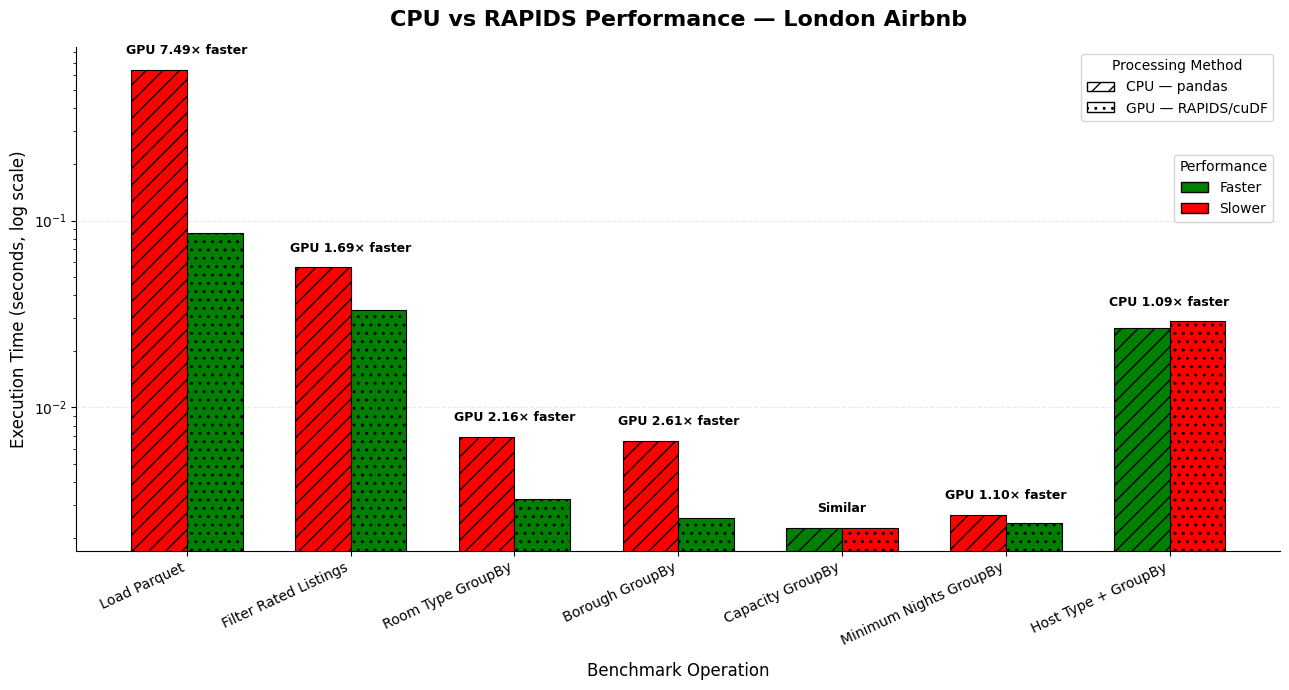

In [16]:
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.patches import Patch

# Data
operations = final_results["Operation"]
cpu_times_plot = final_results["CPU Time (sec)"].to_numpy()
gpu_times_plot = final_results["GPU Time (sec)"].to_numpy()
speedups = final_results["Speedup (CPU/GPU)"].to_numpy()

x = np.arange(len(operations))
width = 0.34

# Green = faster, Red = slower for each operation
cpu_colors = [
    "green" if cpu < gpu else "red"
    for cpu, gpu in zip(cpu_times_plot, gpu_times_plot)
]

gpu_colors = [
    "green" if gpu < cpu else "red"
    for cpu, gpu in zip(cpu_times_plot, gpu_times_plot)
]

# Figure
fig, ax = plt.subplots(figsize=(13, 7))

cpu_bars = ax.bar(
    x - width/2,
    cpu_times_plot,
    width,
    color=cpu_colors,
    edgecolor="black",
    linewidth=0.8,
    hatch="//"
)

gpu_bars = ax.bar(
    x + width/2,
    gpu_times_plot,
    width,
    color=gpu_colors,
    edgecolor="black",
    linewidth=0.8,
    hatch=".."
)

# Log scale because timings vary greatly
ax.set_yscale("log")

# Labels and title
ax.set_title(
    "CPU vs RAPIDS Performance — London Airbnb",
    fontsize=16,
    fontweight="bold",
    pad=15
)

ax.set_ylabel(
    "Execution Time (seconds, log scale)",
    fontsize=12
)

ax.set_xlabel(
    "Benchmark Operation",
    fontsize=12,
    labelpad=10
)

ax.set_xticks(x)
ax.set_xticklabels(
    operations,
    rotation=25,
    ha="right",
    fontsize=10
)

# Light horizontal grid
ax.grid(
    axis="y",
    linestyle="--",
    alpha=0.25
)

ax.set_axisbelow(True)

# Add speedup above each pair
for i, speedup in enumerate(speedups):

    pair_top = max(cpu_times_plot[i], gpu_times_plot[i])

    if speedup > 1.05:
        label = f"GPU {speedup:.2f}× faster"
    elif speedup < 0.95:
        label = f"CPU {1/speedup:.2f}× faster"
    else:
        label = "Similar"

    ax.annotate(
        label,
        xy=(x[i], pair_top),
        xytext=(0, 9),
        textcoords="offset points",
        ha="center",
        va="bottom",
        fontsize=9,
        fontweight="bold"
    )

# Legends
method_legend = [
    Patch(
        facecolor="white",
        edgecolor="black",
        hatch="//",
        label="CPU — pandas"
    ),
    Patch(
        facecolor="white",
        edgecolor="black",
        hatch="..",
        label="GPU — RAPIDS/cuDF"
    )
]

speed_legend = [
    Patch(facecolor="green", edgecolor="black", label="Faster"),
    Patch(facecolor="red", edgecolor="black", label="Slower")
]

legend1 = ax.legend(
    handles=method_legend,
    loc="upper right",
    title="Processing Method"
)

ax.add_artist(legend1)

ax.legend(
    handles=speed_legend,
    loc="upper right",
    bbox_to_anchor=(1, 0.80),
    title="Performance"
)

# Clean appearance
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

fig.tight_layout()

# High-resolution output
plt.savefig(
    "cpu_vs_rapids_performance.png",
    dpi=500,
    bbox_inches="tight"
)

plt.show()

## 5. Interpretation and Decision

The CPU vs RAPIDS benchmark shows that GPU acceleration is beneficial for several operations in the London Airbnb workflow, but the improvement depends on the workload.

### Key Findings

- **Data loading:** RAPIDS loaded the Parquet dataset approximately **7.49× faster**, the largest improvement observed.
- **Filtering:** GPU processing was approximately **1.69× faster** when selecting rated listings.
- **Categorical aggregations:** RAPIDS was approximately **2.16× faster** for room type and **2.61× faster** for borough aggregation.
- **Small aggregations:** Capacity and minimum-night GroupBy operations showed little difference because both CPU and GPU completed them in only a few milliseconds.
- **Feature engineering:** Host-type creation and aggregation was slightly faster on the CPU, showing that GPU acceleration does not benefit every small operation.

### Decision

For this dataset of **92,635 rows × 80 columns**, RAPIDS provides the clearest benefit for data loading and selected aggregation workloads.

However, GPU acceleration should be used **selectively rather than automatically**. For small operations, GPU overhead can reduce or eliminate the performance advantage.

**Overall conclusion:** RAPIDS can accelerate suitable data-processing tasks, while pandas remains competitive for lightweight operations on a dataset of this size.